In [1]:
print("Hello world!")

Hello world!


In [24]:
import pandas as pd
import numpy as np
from dowhy import CausalModel
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from econml.dml import CausalForestDML
import matplotlib.pyplot as plt
from dowhy import CausalModel, gcm
import graphviz

In [19]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print(len(df))
df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)]
print(len(df))
df.head()

6140
5612


,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",True,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670


In [20]:
counts = df['code_location'].value_counts()
print(counts)

code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64


In [42]:
df["verdict"] = df["verdict"].astype(int)
df["apk_size_mb"] = df["apk_size"] / 1000000
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
df["lib_category"] = df["code_location"].apply(lambda x: x if x != "developer_written" else "source")

df["code_location"].value_counts()
df.head()

,alert_description,verdict,artifact_location,app_package_name,version_code,apk_category,sast_tool_name,code_location,3rd_party_library_name,apk_size,apk_size_mb,is_third_party,lib_category
0,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/m.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,14.562465,1,others
1,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/applovin/impl/sdk/utils/StringUtils.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,others,unknown,14562465,14.562465,1,others
2,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,14.562465,1,Android
3,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/ads/zzcgg.java,all.language.translator.hub.malayalamtosamoant...,1,<100,CogniCrypt,Android,com.google.android.gms::play-services-ads-base,14562465,14.562465,1,Android
4,"Constraint ""algorithm in {SHA-256, SHA-384, SH...",1,com/google/android/gms/internal/zzaiy.java,aplus.droitfiscal,37,5k-10k,CogniCrypt,Android,com.google.android.gms::play-services-clearcut,3041670,3.041670,1,Android


In [47]:
causal_graph = """
digraph {
    apk_category -> apk_size_mb;
    apk_category -> is_third_party;
    apk_size_mb -> is_third_party;
    apk_size_mb -> verdict;
    is_third_party -> verdict;
    lib_category -> verdict;
}
"""


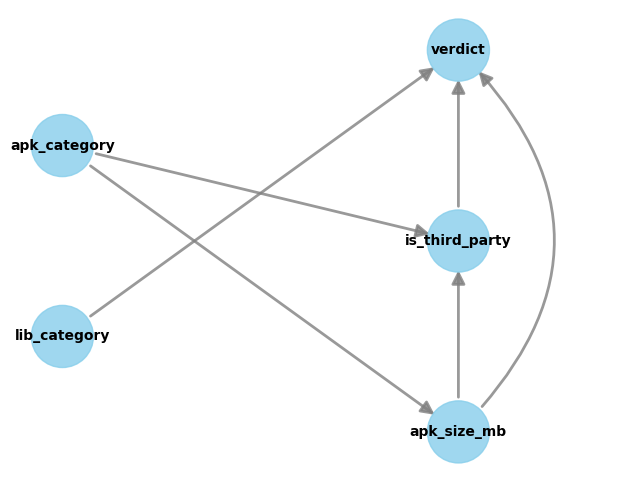

In [48]:
model = CausalModel(
    data=df,
    treatment="is_third_party",
    outcome="verdict",
    graph=causal_graph.replace("\n", " "),
    common_causes=["apk_size_mb", "apk_category", "lib_category"]
)

model.view_model()

In [55]:
identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
print(identified_estimand)


Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                
─────────────────(E[verdict|apk_size_mb])
d[is_third_party]                        
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_size_mb,U) = P(verdict|is_third_party,apk_size_mb)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
        d                                
─────────────────(E[verdict|apk_size_mb])
d[is_third_party]                        
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_size_mb,U) = P(verdict|is_third_party,apk_size_mb)



In [56]:
estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    confidence_intervals=True
)

print(f"Estimated ATE: {estimate}")


Estimated ATE: *** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
        d                                
─────────────────(E[verdict|apk_size_mb])
d[is_third_party]                        
Estimand assumption 1, Unconfoundedness: If U→{is_third_party} and U→verdict then P(verdict|is_third_party,apk_size_mb,U) = P(verdict|is_third_party,apk_size_mb)

## Realized estimand
b: verdict~is_third_party+apk_size_mb
Target units: ate

## Estimate
Mean value: -0.2255880256593015
95.0% confidence interval: (np.float64(-0.26977904490377763), np.float64(-0.08535281539558093))



In [57]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter"
]
for method in refutation_methods:
    ref = model.refute_estimate(identified_estimand, estimate, method_name=method)
    print(f"\nRefuter: {method}\n", ref)


Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.2255880256593015
New effect:-0.22558802565930156
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.2255880256593015
New effect:0.0008891660727013538
p value:0.96


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.2255880256593015
New effect:-0.29100445434298444
p value:0.2

